# Update log (this revision)

This revision addresses four requested checks, each broken out into its own section below:

1. **Data generation is now seeded and repeated across seeds.** `generate_data(seed, ...)` draws from a dedicated `np.random.RandomState(seed)` instead of the ambient numpy global state, so a given seed reproduces the *same dataset*, not just the same model init. Every comparison below is repeated over `N_SEEDS` seeds and reported as **mean +- std**, not a single run.
2. **SVD stability.** `stable_svd(X)` (gesvd driver on CUDA, CPU LAPACK fallback) is used for the forward pass in both the custom analytic-gradient path (`svd_backend="custom"`, the hand-written backward) and a plain-autograd path (`svd_backend="torch"`, gradients flow through `torch.linalg.svd` natively). The "SVD stability test" section compares them directly.
3. **Architecture depth sweep.** `make_feature_extractor(depth)` builds 1, 2, or 3 conv blocks, to check whether OA_BN / OA_RR's advantage over OA survives with a smaller feature extractor, or whether it's an artifact of the specific 3-block architecture.
4. **Training-set-size sweep.** `Ntr` is swept from 800 down to 150 to find where the plain architecture (OA) starts overfitting (low train error, high test error), and whether BN/RR mitigate it.

# Layer Definition

In [1]:
import warnings
import math
import torch
import torch.nn as nn
from collections import deque


def stable_svd(X, full_matrices=False):
    # cusolver's default gesvdj can fail to converge on ill-conditioned / repeated-singular-value
    # matrices (common with grid-structured data). Use the accurate gesvd driver on CUDA,
    # and fall back to CPU LAPACK if it still fails. Gradients flow through both paths.
    try:
        if X.is_cuda:
            return torch.linalg.svd(X, full_matrices=full_matrices, driver='gesvd')
        return torch.linalg.svd(X, full_matrices=full_matrices)
    except torch.linalg.LinAlgError:
        U, S, Vh = torch.linalg.svd(X.cpu(), full_matrices=full_matrices)
        return U.to(X.device), S.to(X.device), Vh.to(X.device)


class StableSVD(torch.autograd.Function):
    """
    Custom analytic-gradient SVD. The forward pass uses `stable_svd` (gesvd
    driver on CUDA, CPU LAPACK fallback) for numerical robustness; the
    backward pass implements the analytic SVD gradient by hand instead of
    relying on autograd through torch.linalg.svd.
    """

    @staticmethod
    def forward(ctx, A):
        U, S, Vh = stable_svd(A, full_matrices=False)

        ctx.save_for_backward(U, S, Vh)
        ctx.original_shape = A.shape

        return U, S, Vh

    @staticmethod
    def backward(ctx, dU, dS, dVh):
        """
        Backward pass for stable SVD.
        Computes gradient w.r.t. input A given gradients on U, S, Vh.
        """
        U, S, Vh = ctx.saved_tensors
        m, n = ctx.original_shape[-2:]

        dtype = U.dtype
        device = U.device

        H = lambda x: x.transpose(-2, -1).conj()
        T = lambda x: x.transpose(-2, -1)

        # Diagonal helpers
        def diag_embed(x):
            return torch.diag_embed(x)

        # Singular value vector to diagonal for broadcasting
        S_mat = S.unsqueeze(-2)
        S_diff = S_mat - S_mat.transpose(-2, -1)

        # F matrix for repeated singular values
        eps = 1e-20
        F = torch.where(S_diff.abs() > eps, 1.0 / S_diff, torch.zeros_like(S_diff))

        # Gradient from singular values
        dA = U @ diag_embed(dS) @ Vh

        # Contributions from U
        Ut_dU = H(U) @ dU
        skew_U = F * (Ut_dU - Ut_dU.transpose(-2, -1))
        dA += U @ skew_U @ diag_embed(S) @ Vh

        # Contributions from V
        V = H(Vh)  # n x k
        Vt_dV = H(V) @ H(dVh)  # k x k
        skew_V = F * (Vt_dV - Vt_dV.transpose(-2, -1))
        dA += U @ diag_embed(S) @ skew_V @ Vh

        # Rectangular adjustments (like JAX)
        # s_inv = 1 / S with stable zero handling
        s_zeros = (S == 0).to(dtype)
        s_inv = 1.0 / (S + s_zeros) - s_zeros  # shape: (k,)

        if m > n:
            dAV = dA @ V
            dA += (dAV - U @ (H(U) @ dAV)) * s_inv
        elif n > m:
            dAHU = H(dA) @ U
            dA += H(dAHU - V @ (Vh @ dAHU)) * s_inv.unsqueeze(1)

        return dA


class RRLayer(nn.Module):
    r"""
    Rank Reduction (RR) layer.

    During training, the layer computes a truncated SVD across the batch
    dimension and reconstructs the input using the top ``rank`` singular
    components.

    During evaluation, the layer projects the input onto a learned inference
    basis obtained from the recent training bases.

    A custom basis can always be supplied through the ``basis`` argument of
    :meth:`forward`, in which case the train/eval behavior is bypassed.

    Args:
        rank (int):
            Number of singular values to retain.

        basis_history_size (int, optional):
            Number of recent batch bases to keep when estimating the inference
            basis. Default: 20.

        svd_backend (str, optional):
            Which SVD implementation to use internally:
              - "custom": ``StableSVD.apply`` -- the hand-written analytic
                backward defined above.
              - "torch": ``stable_svd(...)`` directly -- PyTorch's native
                autograd through ``torch.linalg.svd``.
            Default: "custom".

    Shape:
        - Input: ``(N, *)``
        - Output: ``(N, *)``

    Example:
        >>> rr = RRLayer(rank=8)
        >>> rr.train()
        >>> y = rr(torch.randn(32, 768))

        >>> rr.eval()
        >>> y = rr(torch.randn(32, 768))
    """

    def __init__(
        self,
        rank: int,
        basis_history_size: int = 20,
        svd_backend: str = "custom",
    ):
        super().__init__()

        if rank <= 0:
            raise ValueError(
                f"rank must be positive, got {rank}."
            )

        if basis_history_size <= 0:
            raise ValueError(
                f"basis_history_size must be positive, got "
                f"{basis_history_size}."
            )

        if svd_backend not in ("custom", "torch"):
            raise ValueError(
                f"svd_backend must be 'custom' or 'torch', got {svd_backend!r}."
            )

        self.rank = rank
        self.basis_history_size = basis_history_size
        self.svd_backend = svd_backend

        self.register_buffer(
            "inference_basis",
            None,
            persistent=True,
        )

        self._basis_bank = deque(
            maxlen=basis_history_size,
        )

    def _svd(self, X: torch.Tensor):
        """Dispatches to the configured SVD backend."""
        if self.svd_backend == "custom":
            return StableSVD.apply(X)
        return stable_svd(X, full_matrices=False)

    def extra_repr(self) -> str:
        return (
            f"rank={self.rank}, "
            f"basis_history_size={self.basis_history_size}, "
            f"svd_backend={self.svd_backend!r}"
        )

    def train(self, mode: bool = True):
        """
        Switch between training and evaluation mode.

        When switching from training to evaluation for the first time,
        an inference basis is automatically computed from the stored
        training bases.
        """

        previous_mode = self.training

        super().train(mode)

        if (
            previous_mode
            and not mode
            and self.inference_basis is None
            and len(self._basis_bank) > 0
        ):
            self.finalize_basis()

        return self

    @torch.no_grad()
    def finalize_basis(self) -> None:
        """
        Build the inference basis from the stored training bases.
        """

        if len(self._basis_bank) == 0:
            raise RuntimeError(
                "Cannot finalize basis: no stored bases available."
            )

        device = next(self.parameters(), None)

        if device is None:
            device = self.inference_basis.device \
                if self.inference_basis is not None \
                else self._basis_bank[0].device
        else:
            device = device.device

        W = torch.cat(
            [
                basis.to(device)
                for basis in self._basis_bank
            ],
            dim=1,
        )

        U, _, _ = self._svd(W)

        r = min(self.rank, U.shape[1])

        self.inference_basis = U[:, :r]

    @torch.no_grad()
    def finalize_basis_from_data(self, x: torch.Tensor) -> None:
        """
        Build the inference basis directly from a large batch of real data,
        rather than concatenating many small per-minibatch training bases.

        This gives a basis much closer to a true full-dataset SVD -- which
        is what the downstream layers are implicitly trained to expect --
        instead of an average of noisy, small-sample bases.

        x: shape (N, *), same convention as forward()'s input.
        """
        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        U, _, _ = self._svd(X)
        r = min(self.rank, U.shape[1])
        self.inference_basis = U[:, :r]

    def _validate_inputs(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None,
    ) -> None:
        """
        Validate inputs for RRLayer.
        """

        if not isinstance(x, torch.Tensor):
            raise TypeError(
                f"x must be a torch.Tensor, got {type(x)}."
            )

        if x.ndim < 2:
            raise ValueError(
                "RRLayer expects input of shape (N, ...), "
                f"got shape {tuple(x.shape)}."
            )

        if x.shape[0] == 0:
            raise ValueError(
                "Batch size must be greater than zero."
            )

        if not torch.isfinite(x).all():
            raise ValueError(
                "Input tensor contains NaN or Inf values."
            )

        M = math.prod(x.shape[1:])
        N = x.shape[0]

        rank_max = min(M, N)

        if self.rank > rank_max:
            warnings.warn(
                f"Requested rank={self.rank}, but the maximum "
                f"achievable rank is {rank_max}. "
                f"Using rank={rank_max}.",
                stacklevel=2,
            )

        if basis is not None:

            if not isinstance(basis, torch.Tensor):
                raise TypeError(
                    f"basis must be a torch.Tensor, got {type(basis)}."
                )

            if basis.ndim != 2:
                raise ValueError(
                    "basis must have shape (M, r), "
                    f"got shape {tuple(basis.shape)}."
                )

            if basis.shape[0] != M:
                raise ValueError(
                    f"basis has {basis.shape[0]} rows but "
                    f"expected {M}."
                )

            if basis.shape[1] == 0:
                raise ValueError(
                    "basis must contain at least one column."
                )

            if basis.device != x.device:
                raise ValueError(
                    f"basis is on {basis.device} while "
                    f"x is on {x.device}."
                )

            if basis.dtype != x.dtype:
                raise ValueError(
                    f"basis dtype ({basis.dtype}) does not match "
                    f"x dtype ({x.dtype})."
                )

            if not torch.isfinite(basis).all():
                raise ValueError(
                    "basis contains NaN or Inf values."
                )

    def forward(
        self,
        x: torch.Tensor,
        basis: torch.Tensor | None = None,
        return_factors: bool = False,
    ):
        self._validate_inputs(x, basis)

        original_shape = x.shape
        batch_size = original_shape[0]

        X = torch.movedim(x, 0, -1)
        X = X.reshape(-1, batch_size)

        if basis is not None:

            basis_used = basis

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        elif self.training:

            U, S, Vh = self._svd(X)

            r = min(self.rank, S.shape[0])

            basis_used = U[:, :r]

            coeffs = (
                S[:r].unsqueeze(1)
                * Vh[:r]
            )

            X_hat = basis_used @ coeffs

            self._basis_bank.append(
                basis_used.detach().cpu()
            )

        else:

            if self.inference_basis is None:
                raise RuntimeError(
                    "RRLayer has no inference basis. "
                    "Call finalize_basis() or run training "
                    "before evaluation."
                )

            basis_used = self.inference_basis

            coeffs = basis_used.T @ X

            X_hat = basis_used @ coeffs

        output = X_hat.reshape(
            *original_shape[1:],
            batch_size,
        )

        output = torch.movedim(
            output,
            -1,
            0,
        )

        if return_factors:
            return output, basis_used, coeffs

        return output

# Getting Data

In [2]:
import numpy as np

D = 64        # Dimension of the domain
SIGMA = 0.2   # Gaussian blob width


def gaussian_2d(x, y, x0, y0, sigma):
    return np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))


def generate_data(seed, Ntr=800, Nte=200, D=64, sigma=0.2):
    """
    Generates a fresh train/test split of Gaussian-blob images.

    Unlike drawing from the ambient numpy global RNG state (which makes the
    dataset different every run even with a fixed torch seed for the model),
    this uses a dedicated np.random.RandomState(seed), so a given `seed`
    reproduces the same dataset every time - and different seeds give
    genuinely different datasets, which is what we want when averaging
    results over multiple seeds below.
    """
    rng = np.random.RandomState(seed)

    x = np.linspace(-1, 1, D)
    y = np.linspace(-1, 1, D)
    X, Y = np.meshgrid(x, y)

    x0_tr = rng.uniform(-0.5, 0.5, Ntr)
    y0_tr = rng.uniform(-0.5, 0.5, Ntr)
    train_data = np.stack(
        [gaussian_2d(X, Y, x0_tr[i], y0_tr[i], sigma) for i in range(Ntr)], axis=-1
    )

    x0_te = rng.uniform(-0.5, 0.5, Nte)
    y0_te = rng.uniform(-0.5, 0.5, Nte)
    test_data = np.stack(
        [gaussian_2d(X, Y, x0_te[i], y0_te[i], sigma) for i in range(Nte)], axis=-1
    )

    # Normalize the data
    train_data = (train_data - np.mean(train_data)) / np.std(train_data)
    test_data = (test_data - np.mean(test_data)) / np.std(test_data)

    # Permute image tensors to (N, C, H, W)
    x_train = np.moveaxis(np.expand_dims(train_data, 0), -1, 0).astype(np.float32)
    x_test = np.moveaxis(np.expand_dims(test_data, 0), -1, 0).astype(np.float32)

    # Target coordinate tensors (N, 2)
    p_train = np.stack([x0_tr, y0_tr], axis=-1).astype(np.float32)
    p_test = np.stack([x0_te, y0_te], axis=-1).astype(np.float32)

    return x_train, p_train, x_test, p_test


# Demo call -- used by the preview plot below and by the "Prepare dataset" section.
x_train, p_train, x_test, p_test = generate_data(seed=0, Ntr=800, Nte=200, D=D, sigma=SIGMA)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("p_train shape:", p_train.shape)
print("p_test shape:", p_test.shape)

x_train shape: (800, 1, 64, 64)
x_test shape: (200, 1, 64, 64)
p_train shape: (800, 2)
p_test shape: (200, 2)


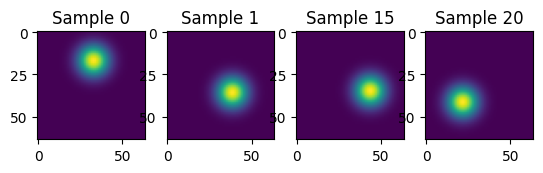

In [3]:
import matplotlib.pyplot as plt
plt.subplot(1, 4, 1)
plt.imshow(x_train[0, 0, :, :], cmap='viridis')
plt.title('Sample 0')
plt.subplot(1, 4, 2)
plt.imshow(x_train[1, 0, :, :], cmap='viridis')
plt.title('Sample 1')
plt.subplot(1, 4, 3)
plt.imshow(x_test[15, 0, :, :], cmap='viridis')
plt.title('Sample 15')
plt.subplot(1, 4, 4)
plt.imshow(x_test[20, 0, :, :], cmap='viridis')
plt.title('Sample 20')
plt.show()

# Prepare dataset

In [4]:
import torch
from torch.utils.data import Dataset

class GaussianCenterDataset(Dataset):
    """
    Wraps the generated Gaussian-blob images and their (x0, y0) centers.

    x: (N, 1, 64, 64) float32 image tensor
    p: (N, 2)         float32 center-position tensor
    """
    def __init__(self, x: np.ndarray, p: np.ndarray):
        self.x = torch.as_tensor(x, dtype=torch.float32)
        self.p = torch.as_tensor(p, dtype=torch.float32)

        assert self.x.shape[0] == self.p.shape[0], (
            f"Mismatched sample count: x has {self.x.shape[0]}, "
            f"p has {self.p.shape[0]}"
        )

    def __len__(self):
        return self.x.shape[0]

    def __getitem__(self, idx):
        return self.x[idx], self.p[idx]

In [5]:
from torch.utils.data import DataLoader

batch_size = 32  # < smallest classifier width (32), keeps StableSVD on the m > n branch
                  # for all 3 RRLayers, matching the official example's regime

train_dataset = GaussianCenterDataset(x_train, p_train)
test_dataset = GaussianCenterDataset(x_test, p_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

xb, pb = next(iter(train_loader))
print("batch x shape:", xb.shape)
print("batch p shape:", pb.shape)
print(f"batches per epoch: {len(train_loader)}")

batch x shape: torch.Size([32, 1, 64, 64])
batch p shape: torch.Size([32, 2])
batches per epoch: 25


# common make_feature_extractor()

In [6]:
def make_feature_extractor(depth: int = 3):
    """
    Builds `depth` conv-relu-maxpool blocks. Channels go 1 -> 8 -> 16 -> 32;
    spatial size halves at each block (D=64 -> 32 -> 16 -> 8 for depth=3,
    matching the original fixed 3-block extractor).

    depth=1: 1 block  (shallowest)
    depth=2: 2 blocks
    depth=3: 3 blocks (original architecture)
    """
    channel_sizes = [1, 8, 16, 32]
    if not (1 <= depth <= len(channel_sizes) - 1):
        raise ValueError(f"depth must be in [1, {len(channel_sizes) - 1}], got {depth}.")

    layers = []
    for i in range(depth):
        layers += [
            nn.Conv2d(channel_sizes[i], channel_sizes[i + 1], kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        ]
    return nn.Sequential(*layers)


def feature_extractor_output_dim(depth: int, D: int = 64):
    """Flattened output size of make_feature_extractor(depth) for a D x D input."""
    channel_sizes = [1, 8, 16, 32]
    spatial = D // (2 ** depth)
    return channel_sizes[depth] * spatial * spatial

# Original Architecture

In [7]:
import torch
import torch.nn as nn


class OA(nn.Module):
    def __init__(self, depth: int = 3, D: int = 64):
        super(OA, self).__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

# Batch_Norm Architecture

In [8]:
class OA_BN(nn.Module):
    def __init__(self, depth: int = 3, D: int = 64):
        super(OA_BN, self).__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.bottleneck = nn.BatchNorm1d(flat_dim)   # single bottleneck, once
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.bottleneck(x)
        return self.classifier(x)

# RR_Layers Architecture

In [9]:
class OA_RR(nn.Module):
    def __init__(self, rank: int = 8, depth: int = 3, D: int = 64, svd_backend: str = "custom"):
        super(OA_RR, self).__init__()
        self.features = make_feature_extractor(depth)
        flat_dim = feature_extractor_output_dim(depth, D)
        self.bottleneck = RRLayer(rank=rank, svd_backend=svd_backend)   # single bottleneck, once
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, 128), nn.ReLU(inplace=True),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.bottleneck(x)
        return self.classifier(x)

# Experiment configuration & model builder

In [10]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Global experiment configuration ----
N_SEEDS = 8                              # seeds per experiment; bump to 10 if runtime allows
SEEDS = list(range(2000, 2000 + N_SEEDS))

NTR_DEFAULT = 800
NTE_DEFAULT = 200
RANK = 8
EPOCHS_DEFAULT = 20
LR_DEFAULT = 1e-3
BATCH_SIZE = 32
DEPTH_DEFAULT = 3


def build_models(seed, depth=DEPTH_DEFAULT, rank=RANK, D=64, svd_backend="custom"):
    """
    Builds OA / OA_BN / OA_RR, re-applying the SAME seed before each
    constructor call, so their shared Conv2d/Linear layers get identical
    initial weights (verified positionally below) -- the only difference
    between the three models is the bottleneck.
    """
    torch.manual_seed(seed)
    model_oa = OA(depth=depth, D=D)

    torch.manual_seed(seed)
    model_bn = OA_BN(depth=depth, D=D)

    torch.manual_seed(seed)
    model_rr = OA_RR(rank=rank, depth=depth, D=D, svd_backend=svd_backend)

    return {"OA": model_oa, "OA_BN": model_bn, "OA_RR": model_rr}


print(f"Using device: {device}")
print(f"N_SEEDS={N_SEEDS}, SEEDS={SEEDS}")

Using device: cpu
N_SEEDS=8, SEEDS=[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]


# Sanity check: shared initial weights across OA / OA_BN / OA_RR

In [11]:
def get_ordered_learnable_layers(model: nn.Module):
    """
    Returns a list of (weight, bias) tuples for every Conv2d/Linear
    layer in the model, in forward-pass order -- ignoring any
    BatchNorm/RRLayer/ReLU/etc. layers interspersed between them.
    """
    layers = []
    for module in model.modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            layers.append((module.weight, module.bias))
    return layers


def compare_shared_weights_by_position(models: dict):
    """
    Compares Conv2d/Linear weights positionally (1st conv vs 1st conv,
    2nd linear vs 2nd linear, etc.) rather than by state_dict key name,
    so BN/RRLayer insertions don't shift the comparison.
    """
    names = list(models.keys())
    ordered_layers = {n: get_ordered_learnable_layers(m) for n, m in models.items()}

    lengths = {n: len(ordered_layers[n]) for n in names}
    n_layers = min(lengths.values())

    for n in names:
        if lengths[n] != n_layers:
            print(f"warning: {n} has {lengths[n]} Conv2d/Linear layers, "
                  f"expected {max(lengths.values())} (mismatched architecture depth) "
                  f"-- only comparing the first {n_layers} shared positions")

    print(f"Comparing {n_layers} positionally-matched Conv2d/Linear layers "
          f"across: {names}\n" + "-" * 60)

    all_match = True
    for i in range(n_layers):
        ref_w, ref_b = ordered_layers[names[0]][i]
        for n in names[1:]:
            other_w, other_b = ordered_layers[n][i]

            if ref_w.shape != other_w.shape:
                print(f"[SHAPE MISMATCH] layer #{i}: "
                      f"{names[0]}={tuple(ref_w.shape)} vs {n}={tuple(other_w.shape)}")
                all_match = False
                continue

            w_match = torch.equal(ref_w, other_w)
            b_match = torch.equal(ref_b, other_b) if ref_b is not None else True

            if not (w_match and b_match):
                print(f"[MISMATCH] layer #{i} ({names[0]} vs {n}): "
                      f"weight_match={w_match}, bias_match={b_match}")
                all_match = False

    if all_match:
        print("All positionally-matched Conv2d/Linear layers have identical weights.")
    else:
        print("Some layers differ -- see above.")

    return all_match


_demo_models = build_models(seed=SEEDS[0])
compare_shared_weights_by_position(_demo_models)

Comparing 5 positionally-matched Conv2d/Linear layers across: ['OA', 'OA_BN', 'OA_RR']
------------------------------------------------------------
All positionally-matched Conv2d/Linear layers have identical weights.


True

# Training / evaluation / multi-seed infrastructure

In [12]:
import numpy as np
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader


def train_and_evaluate(models, train_loader, test_loader, device, epochs=20, lr=1e-3, verbose=False):
    criterion = nn.MSELoss()
    optimizers = {name: optim.Adam(m.parameters(), lr=lr) for name, m in models.items()}
    for m in models.values():
        m.to(device)

    train_loss_history = {name: [] for name in models}

    for epoch in range(epochs):
        for m in models.values():
            m.train()

        running = {name: 0.0 for name in models}
        for x_batch, p_batch in train_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            for name, model in models.items():
                opt = optimizers[name]
                opt.zero_grad()
                preds = model(x_batch)
                loss = criterion(preds, p_batch)
                loss.backward()
                opt.step()
                running[name] += loss.item() * x_batch.size(0)

        for name in models:
            train_loss_history[name].append(running[name] / len(train_loader.dataset))

        if verbose:
            msg = " | ".join(f"{name}: {train_loss_history[name][-1]:.4f}" for name in models)
            print(f"Epoch [{epoch + 1}/{epochs}] {msg}")

    for m in models.values():
        m.eval()

    results = {}
    with torch.no_grad():
        test_losses = {name: 0.0 for name in models}
        l2_dists = {name: [] for name in models}

        for x_batch, p_batch in test_loader:
            x_batch, p_batch = x_batch.to(device), p_batch.to(device)
            for name, model in models.items():
                preds = model(x_batch)
                loss = criterion(preds, p_batch)
                test_losses[name] += loss.item() * x_batch.size(0)
                l2_dists[name].append(torch.linalg.norm(preds - p_batch, dim=1))

        for name in models:
            cat = torch.cat(l2_dists[name])
            test_mse = test_losses[name] / len(test_loader.dataset)
            train_mse_final = train_loss_history[name][-1]
            results[name] = {
                "test_mse": test_mse,
                "test_mean_l2": cat.mean().item(),
                "test_med_l2": cat.median().item(),
                "train_mse_final": train_mse_final,
                "gap": test_mse - train_mse_final,   # >0 => overfitting on this run
            }

    return results, train_loss_history


def run_single_experiment(seed, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT, rank=RANK,
                           epochs=EPOCHS_DEFAULT, D=64, sigma=SIGMA, batch_size=BATCH_SIZE,
                           lr=LR_DEFAULT, svd_backend="custom", device=device, verbose=False):
    """Runs one full seed: fresh data -> fresh models (shared init) -> train -> eval."""
    x_tr, p_tr, x_te, p_te = generate_data(seed, Ntr=Ntr, Nte=Nte, D=D, sigma=sigma)

    train_loader = DataLoader(
        GaussianCenterDataset(x_tr, p_tr),
        batch_size=min(batch_size, Ntr), shuffle=True, drop_last=True,
    )
    test_loader = DataLoader(
        GaussianCenterDataset(x_te, p_te),
        batch_size=min(batch_size, Nte), shuffle=False,
    )

    models = build_models(seed, depth=depth, rank=rank, D=D, svd_backend=svd_backend)
    results, train_hist = train_and_evaluate(
        models, train_loader, test_loader, device, epochs=epochs, lr=lr, verbose=verbose
    )
    return results, train_hist


def run_multi_seed(seeds, **kwargs):
    """
    Repeats run_single_experiment across `seeds` and aggregates.
    Returns agg = {model_name: {metric_name: np.array of per-seed values}}.
    """
    per_seed_results = []
    for s in seeds:
        results, _ = run_single_experiment(seed=s, **kwargs)
        per_seed_results.append(results)

    model_names = list(per_seed_results[0].keys())
    metric_names = list(per_seed_results[0][model_names[0]].keys())

    agg = {
        name: {
            metric: np.array([r[name][metric] for r in per_seed_results])
            for metric in metric_names
        }
        for name in model_names
    }
    return agg, per_seed_results


colors = {'OA': 'tab:blue', 'OA_BN': 'tab:orange', 'OA_RR': 'tab:green'}


def plot_mean_std(agg, metrics=("test_mse", "test_mean_l2", "test_med_l2"), suptitle=None):
    """Bar plot of mean +- std across seeds, one panel per metric, for OA/OA_BN/OA_RR."""
    names = list(agg.keys())
    fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 4.5))
    if len(metrics) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics):
        means = [agg[n][metric].mean() for n in names]
        stds = [agg[n][metric].std() for n in names]
        ax.bar(names, means, yerr=stds, capsize=6,
               color=[colors.get(n) for n in names], alpha=0.85)
        ax.set_title(metric)
        ax.grid(True, axis='y', alpha=0.3)

    if suptitle:
        plt.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


def plot_sweep(sweep_values, agg_list, metric, xlabel, title=None, ylabel=None, ax=None):
    """Grouped bar chart of mean +- std vs a swept variable (depth, Ntr, ...)."""
    model_names = list(agg_list[0].keys())
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(7, 5))

    n_models = len(model_names)
    width = 0.8 / n_models
    x_base = np.arange(len(sweep_values))

    for i, name in enumerate(model_names):
        means = [agg[name][metric].mean() for agg in agg_list]
        stds = [agg[name][metric].std() for agg in agg_list]
        offset = (i - (n_models - 1) / 2) * width
        ax.bar(x_base + offset, means, width, yerr=stds, capsize=4,
               label=name, color=colors.get(name), alpha=0.85)

    ax.set_xticks(x_base)
    ax.set_xticklabels([str(v) for v in sweep_values])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or f"{metric} vs {xlabel}")
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)

    if own_fig:
        plt.tight_layout()
        plt.show()

# Baseline sanity check (single seed)

In [13]:
print("Baseline sanity check: single seed, depth=3, Ntr=800\n" + "=" * 60)

baseline_results, baseline_train_hist = run_single_experiment(
    seed=SEEDS[0], Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
    rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom", verbose=True,
)

print("\nFinal test metrics:")
for name, m in baseline_results.items():
    print(f"  {name:>5} | Test MSE: {m['test_mse']:.4f} | Mean L2: {m['test_mean_l2']:.4f} "
          f"| Med L2: {m['test_med_l2']:.4f} | Train MSE: {m['train_mse_final']:.4f} | Gap: {m['gap']:.4f}")

Baseline sanity check: single seed, depth=3, Ntr=800
Epoch [1/20] OA: 0.0120 | OA_BN: 0.0703 | OA_RR: 0.0127
Epoch [2/20] OA: 0.0003 | OA_BN: 0.0120 | OA_RR: 0.0009
Epoch [3/20] OA: 0.0000 | OA_BN: 0.0085 | OA_RR: 0.0003
Epoch [4/20] OA: 0.0000 | OA_BN: 0.0060 | OA_RR: 0.0002
Epoch [5/20] OA: 0.0000 | OA_BN: 0.0046 | OA_RR: 0.0001
Epoch [6/20] OA: 0.0000 | OA_BN: 0.0044 | OA_RR: 0.0001
Epoch [7/20] OA: 0.0000 | OA_BN: 0.0033 | OA_RR: 0.0001
Epoch [8/20] OA: 0.0000 | OA_BN: 0.0030 | OA_RR: 0.0001
Epoch [9/20] OA: 0.0000 | OA_BN: 0.0034 | OA_RR: 0.0001
Epoch [10/20] OA: 0.0000 | OA_BN: 0.0030 | OA_RR: 0.0001
Epoch [11/20] OA: 0.0000 | OA_BN: 0.0028 | OA_RR: 0.0002
Epoch [12/20] OA: 0.0000 | OA_BN: 0.0022 | OA_RR: 0.0003
Epoch [13/20] OA: 0.0000 | OA_BN: 0.0014 | OA_RR: 0.0002
Epoch [14/20] OA: 0.0000 | OA_BN: 0.0016 | OA_RR: 0.0003
Epoch [15/20] OA: 0.0000 | OA_BN: 0.0023 | OA_RR: 0.0002
Epoch [16/20] OA: 0.0000 | OA_BN: 0.0018 | OA_RR: 0.0001
Epoch [17/20] OA: 0.0000 | OA_BN: 0.0016 | O

# Baseline plots

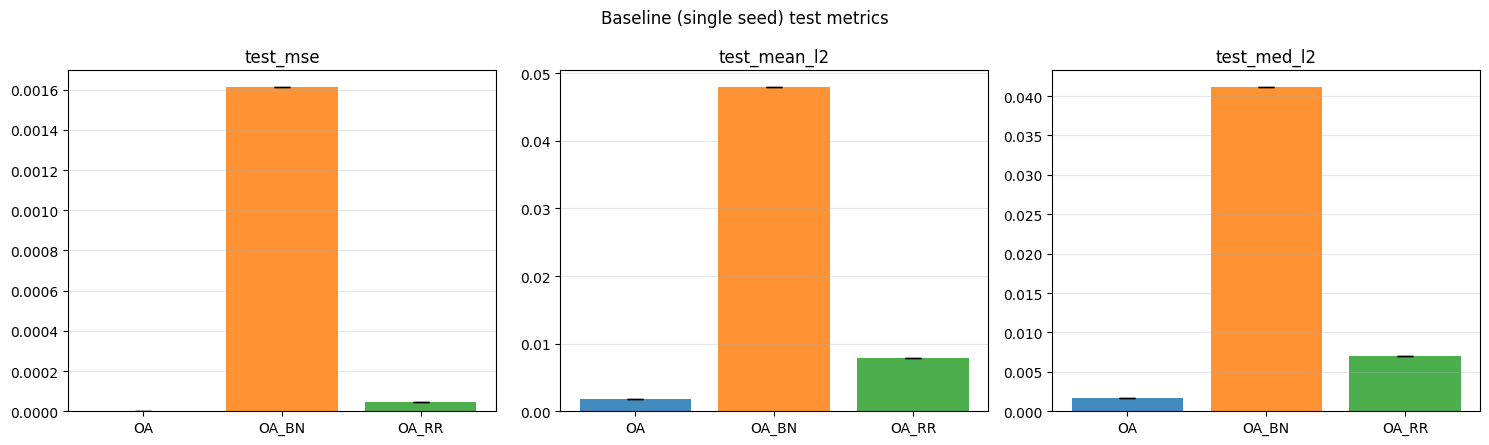

In [14]:
# Reuse plot_mean_std by wrapping the single-seed result in length-1 arrays
baseline_agg = {
    name: {k: np.array([v]) for k, v in m.items()}
    for name, m in baseline_results.items()
}
plot_mean_std(baseline_agg, metrics=("test_mse", "test_mean_l2", "test_med_l2"),
              suptitle="Baseline (single seed) test metrics")

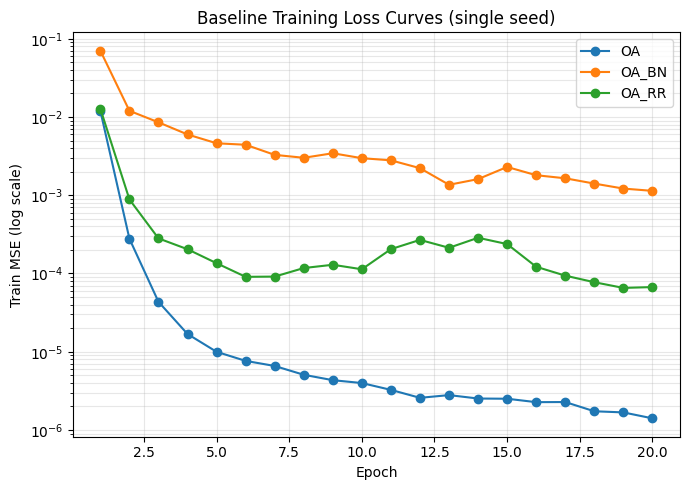

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, hist in baseline_train_hist.items():
    ax.plot(range(1, len(hist) + 1), hist, marker='o', label=name, color=colors[name])
ax.set_yscale('log')
ax.set_xlabel('Epoch')
ax.set_ylabel('Train MSE (log scale)')
ax.set_title('Baseline Training Loss Curves (single seed)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Multi-seed comparison (mean ± std)

Running baseline multi-seed comparison: 8 seeds, depth=3, Ntr=800

Mean +- std across seeds:
     OA | Test MSE: 0.0000 +- 0.0000 | Mean L2: 0.0020 +- 0.0004 | Med L2: 0.0018 +- 0.0003
  OA_BN | Test MSE: 0.0014 +- 0.0008 | Mean L2: 0.0450 +- 0.0155 | Med L2: 0.0421 +- 0.0171
  OA_RR | Test MSE: 0.0001 +- 0.0001 | Mean L2: 0.0095 +- 0.0056 | Med L2: 0.0084 +- 0.0049


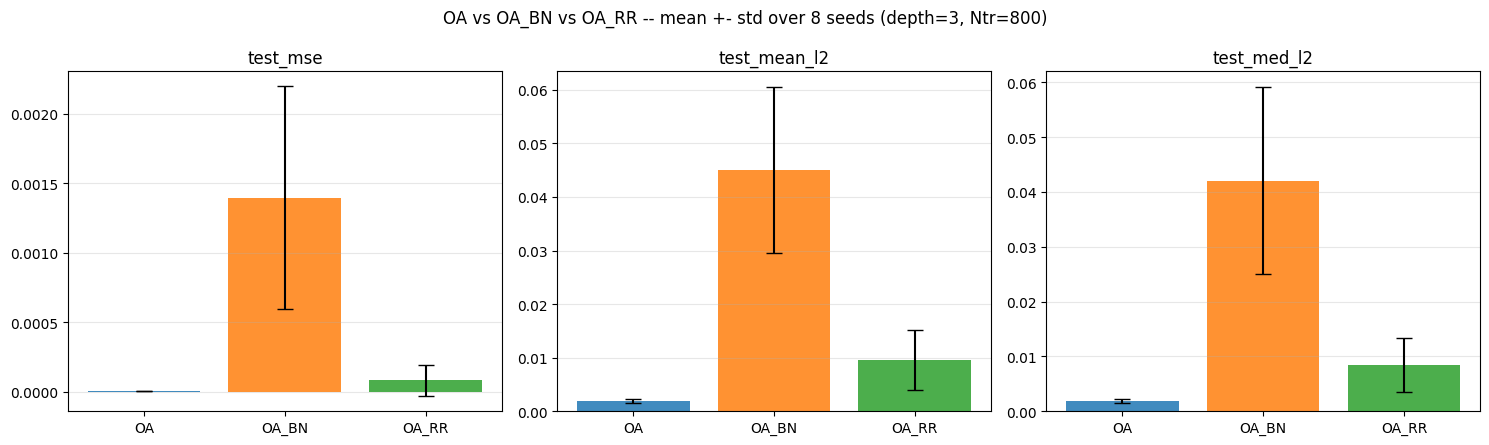

In [16]:
print(f"Running baseline multi-seed comparison: {N_SEEDS} seeds, depth={DEPTH_DEFAULT}, "
      f"Ntr={NTR_DEFAULT}\n" + "=" * 60)

baseline_agg_multi, baseline_per_seed = run_multi_seed(
    seeds=SEEDS, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
    rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom",
)

print("\nMean +- std across seeds:")
for name, m in baseline_agg_multi.items():
    print(f"  {name:>5} | Test MSE: {m['test_mse'].mean():.4f} +- {m['test_mse'].std():.4f}"
          f" | Mean L2: {m['test_mean_l2'].mean():.4f} +- {m['test_mean_l2'].std():.4f}"
          f" | Med L2: {m['test_med_l2'].mean():.4f} +- {m['test_med_l2'].std():.4f}")

plot_mean_std(baseline_agg_multi, metrics=("test_mse", "test_mean_l2", "test_med_l2"),
              suptitle=f"OA vs OA_BN vs OA_RR -- mean +- std over {N_SEEDS} seeds "
                       f"(depth={DEPTH_DEFAULT}, Ntr={NTR_DEFAULT})")

# (does BN/RR help independent of extractor depth?)

Running depth sweep: [1, 2, 3], 8 seeds each, Ntr=800
  depth=1 ...
  depth=2 ...
  depth=3 ...


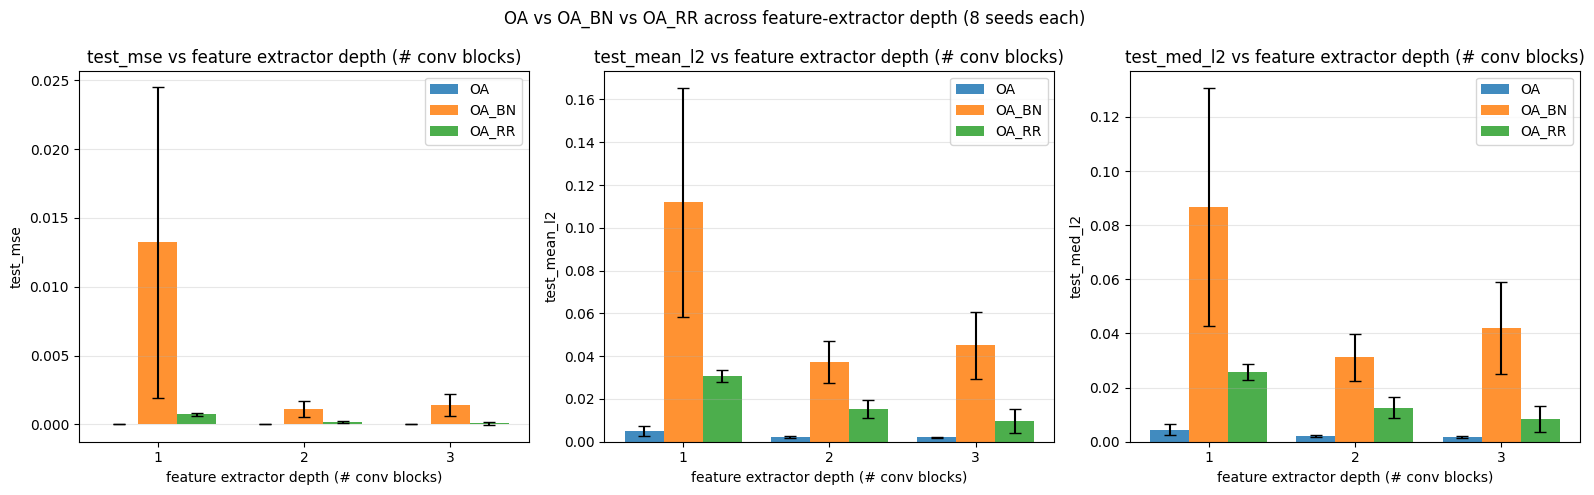

In [18]:
DEPTHS = [1, 2, 3]   # 1 = shallowest (1 conv block), 3 = original extractor

print(f"Running depth sweep: {DEPTHS}, {N_SEEDS} seeds each, Ntr={NTR_DEFAULT}\n" + "=" * 60)

depth_aggs = []
for depth in DEPTHS:
    print(f"  depth={depth} ...")
    agg, _ = run_multi_seed(
        seeds=SEEDS, Ntr=NTR_DEFAULT, Nte=NTE_DEFAULT, depth=depth,
        rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom",
    )
    depth_aggs.append(agg)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ("test_mse", "test_mean_l2", "test_med_l2")):
    plot_sweep(DEPTHS, depth_aggs, metric, xlabel="feature extractor depth (# conv blocks)", ax=ax)
plt.suptitle(f"OA vs OA_BN vs OA_RR across feature-extractor depth ({N_SEEDS} seeds each)")
plt.tight_layout()
plt.show()

# (when does OA start overfitting, and do BN/RR help?)

Running training-set-size sweep: [800, 500, 300, 150], 8 seeds each, depth=3
  Ntr=800 ...
  Ntr=500 ...
  Ntr=300 ...
  Ntr=150 ...


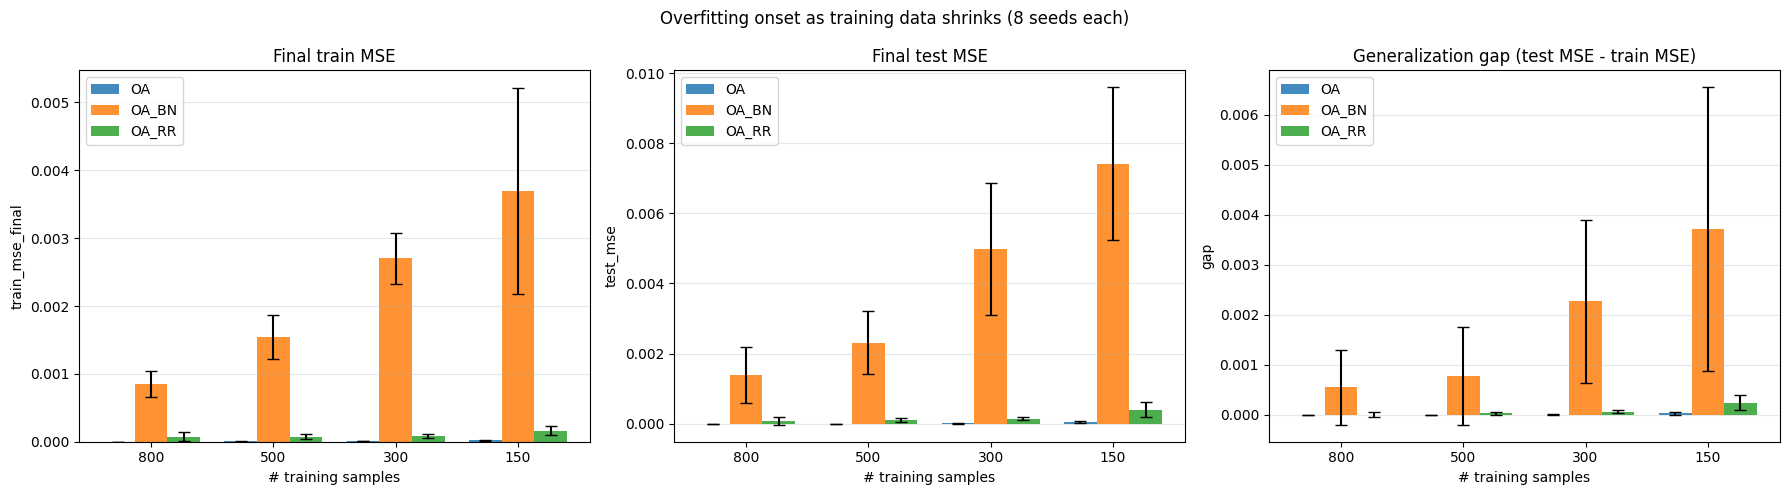

In [19]:
NTR_SWEEP = [800, 500, 300, 150]

print(f"Running training-set-size sweep: {NTR_SWEEP}, {N_SEEDS} seeds each, depth={DEPTH_DEFAULT}\n"
      + "=" * 60)

ntr_aggs = []
for ntr in NTR_SWEEP:
    print(f"  Ntr={ntr} ...")
    agg, _ = run_multi_seed(
        seeds=SEEDS, Ntr=ntr, Nte=NTE_DEFAULT, depth=DEPTH_DEFAULT,
        rank=RANK, epochs=EPOCHS_DEFAULT, svd_backend="custom",
    )
    ntr_aggs.append(agg)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_sweep(NTR_SWEEP, ntr_aggs, "train_mse_final", xlabel="# training samples",
           title="Final train MSE", ax=axes[0])
plot_sweep(NTR_SWEEP, ntr_aggs, "test_mse", xlabel="# training samples",
           title="Final test MSE", ax=axes[1])
plot_sweep(NTR_SWEEP, ntr_aggs, "gap", xlabel="# training samples",
           title="Generalization gap (test MSE - train MSE)", ylabel="gap", ax=axes[2])
plt.suptitle(f"Overfitting onset as training data shrinks ({N_SEEDS} seeds each)")
plt.tight_layout()
plt.show()